
BA Demo: Data Simulation + Notebook/SQL Flow
-------------------------------------------
对照文档：
- 表结构：dim_user / fact_order / bridge_order_item / dim_item / dim_campaign
- 分析模块：N0 ~ N4，对应 PPT P3~P8 


In [1]:
import os
from datetime import timedelta
import numpy as np
import pandas as pd
np.random.seed(42)

In [2]:
# =========================================================
# 1. Data Simulation（数据模拟，对应文档 1.2）
# =========================================================

# 基础参数
n_users = 5000
start_date = pd.Timestamp("2024-10-01")
end_date = pd.Timestamp("2025-03-31")
date_range = (end_date - start_date).days

# 1) 用户表 dim_user
user_ids = np.arange(1, n_users + 1)
signup_dates = [
    start_date + timedelta(days=int(np.random.beta(2, 5) * date_range))
    for _ in user_ids
]
cities = np.random.choice(["Tier1", "Tier2", "Tier3"], size=n_users, p=[0.3, 0.4, 0.3])
acq_channels = np.random.choice(
    ["Paid_Search", "Paid_Social", "Referral", "Organic"],
    # 付费搜索、付费社群、推荐、自然流量
    size=n_users,
    p=[0.25, 0.25, 0.15, 0.35],
)
devices = np.random.choice(["iOS", "Android", "Web"], size=n_users, p=[0.4, 0.4, 0.2])
dim_user = pd.DataFrame(
    {
        "user_id": user_ids,
        "signup_time": signup_dates,
        "city": cities,
        "acquisition_channel": acq_channels,
        "first_touch_channel": acq_channels,
        "device_type": devices,
    }
)

# 2) 订单表 fact_order（先决定下单人数与频次）
#def simulate_orders_for_user(user_row: pd.Series):
#    # 新用户首单概率 & 复购频次按渠道做差异
#    base_first_prob = (
#        0.4
#        if user_row["acquisition_channel"] in ["Referral", "Organic"]
#        else 0.3
#    )
#    if np.random.rand() > base_first_prob:
#        return []  # no orders
#    n_orders = 1 + np.random.poisson(1.0)  # 平均 2 单上下
#    orders = []
#    first_order_date = user_row["signup_time"] + timedelta(
#        days=int(np.random.exponential(scale=5))
#    ) #假设第一单，是首次注册后的随机一天
#    for k in range(n_orders):
#        order_time = first_order_date + timedelta(
#            days=int(np.random.exponential(scale=20 * k + 1))
#        ) # 算第二单的时间
#        if order_time > end_date:
#            break
#        pay_amount = np.random.gamma(shape=3, scale=30)  # AOV around 90
#        discount = np.random.choice([0, 5, 10, 20], p=[0.4, 0.3, 0.2, 0.1])
#        delivery_type = np.random.choice(["Instant", "NextDay"], p=[0.6, 0.4])
#        payment_method = np.random.choice(
#            ["Card", "Wallet", "COD"], p=[0.5, 0.3, 0.2]
#        )
#        is_refunded = np.random.rand() < 0.05
#        orders.append(
#            {
#                "user_id": user_row["user_id"],
#                "order_time": order_time,
#                "pay_amount": round(max(pay_amount - discount, 5), 2),
#                "discount_amount": discount,
#                "delivery_type": delivery_type,
#                "payment_method": payment_method,
#                "is_refunded": int(is_refunded),  #订单取消已退款
#            }
#        )
#    return orders
#orders_list = []
#for _, row in dim_user.iterrows():
#    orders_list.extend(simulate_orders_for_user(row))
#fact_order = pd.DataFrame(orders_list)
#if fact_order.empty:
#    raise RuntimeError("No orders simulated; try adjusting parameters.")
#fact_order["order_id"] = np.arange(1, len(fact_order) + 1)

# 3) 品类 & 明细表 dim_item（先生成，后面订单金额从明细汇总推导，保证口径一致）
categories = ["Food", "Beverage", "Fresh", "Retail"]
price_bands = ["Low", "Mid", "High"]

items = []
for item_id in range(1, 201):
    category = np.random.choice(categories)
    price_band = np.random.choice(price_bands, p=[0.4, 0.4, 0.2])
    base_price = {"Low": 20, "Mid": 60, "High": 150}[price_band]
    price = np.random.normal(base_price, base_price * 0.2)
    cost = price * np.random.uniform(0.6, 0.8)
    items.append(
        {
            "item_id": item_id,
            "category": category,
            "price_band": price_band,
            "standard_cost": round(cost, 2),
            "gross_margin_rate": round(1 - cost / price, 2),
            "is_key_sku": int(item_id <= 30),
        }
    )
dim_item = pd.DataFrame(items)   #品类表

#order_items = []
#for _, o in fact_order.iterrows():
#    n_lines = 1 + np.random.poisson(1)
#    chosen_items = dim_item.sample(n_lines, replace=True)
#    for _, it in chosen_items.iterrows():
#        qty = np.random.randint(1, 4)
#        item_price = it["standard_cost"] / (1 - it["gross_margin_rate"])
#        order_items.append(
#            {
#                "order_id": o["order_id"],
#                "item_id": it["item_id"],
#                "quantity": qty,
#                "item_price": round(item_price, 2),
#                "item_cost": round(it["standard_cost"], 2),
#            }
#        )
#bridge_order_item = pd.DataFrame(order_items)


# 给每个 SKU 预先算出标价（list price），便于后面算 gmv_items
dim_item["item_price"] = (
    dim_item["standard_cost"] / (1 - dim_item["gross_margin_rate"])
).round(2)

# 3) 订单表 fact_order + 明细表 bridge_order_item
# 核心口径：gmv_items = Σ(item_price*qty)；discount_amount 从 gmv_items 派生；pay_amount = gmv_items - discount_amount
order_rows = []
order_item_rows = []
order_id_seq = 1

def simulate_orders_for_user(user_row, order_id_start):
    # 新用户首单概率 & 复购频次可按渠道/城市做差异
    base_first_prob = 0.4 if user_row["acquisition_channel"] in ["Referral", "Organic"] else 0.3
    if np.random.rand() > base_first_prob:
        return [], [], order_id_start

    n_orders = 1 + np.random.poisson(1.0)  # 平均 2 单上下
    first_order_date = user_row["signup_time"] + timedelta(days=int(np.random.exponential(scale=5)))

    o_rows = []
    oi_rows = []
    oid = order_id_start

    for k in range(n_orders):
        order_time = first_order_date + timedelta(days=int(np.random.exponential(scale=20 * k + 1)))
        if order_time > end_date:
            break

        # 先生成明细行（决定 gmv_items/cogs_items）
        n_lines = 1 + np.random.poisson(1)
        chosen = dim_item.sample(n_lines, replace=True)

        gmv_items = 0.0
        cogs_items = 0.0
        for _, it in chosen.iterrows():
            qty = int(np.random.randint(1, 4))
            line_gmv = float(it["item_price"]) * qty
            line_cogs = float(it["standard_cost"]) * qty
            gmv_items += line_gmv
            cogs_items += line_cogs
            oi_rows.append({
                "order_id": oid,
                "item_id": int(it["item_id"]),
                "quantity": qty,
                "item_price": float(it["item_price"]),
                "item_cost": float(it["standard_cost"]),
            })

        # 折扣从 gmv_items 派生（也可替换成“固定金额券”）
        discount_rate = np.random.choice([0.00, 0.05, 0.10, 0.20], p=[0.4, 0.3, 0.2, 0.1])
        discount_amount = round(min(gmv_items * discount_rate, max(gmv_items - 5.0, 0.0)), 2)
        pay_amount = round(max(gmv_items - discount_amount, 5.0), 2)  # 实付（= GMV 实付口径）

        delivery_type = np.random.choice(["Instant", "NextDay"], p=[0.6, 0.4])
        payment_method = np.random.choice(["Card", "Wallet", "COD"], p=[0.5, 0.3, 0.2])
        is_refunded = int(np.random.rand() < 0.05)

        o_rows.append({
            "order_id": oid,
            "user_id": int(user_row["user_id"]),
            "order_time": order_time,
            "pay_amount": pay_amount,
            "discount_amount": discount_amount,
            "delivery_type": delivery_type,
            "payment_method": payment_method,
            "is_refunded": is_refunded,
        })
        oid += 1

    return o_rows, oi_rows, oid

for _, row in dim_user.iterrows():
    o, oi, order_id_seq = simulate_orders_for_user(row, order_id_seq)
    order_rows.extend(o)
    order_item_rows.extend(oi)

fact_order = pd.DataFrame(order_rows)
bridge_order_item = pd.DataFrame(order_item_rows)


# 4) dim_campaign（为渠道 CAC / 贡献利润准备简单成本表，对齐 SQL 示例）活动与成本
campaign_rows = []
campaign_id = 1
for ch in ["Paid_Search", "Paid_Social", "Referral"]:
    # 在分析期内模拟 2~3 个 campaign
    n_campaigns = np.random.randint(2, 4)
    for _ in range(n_campaigns):
        campaign_type = np.random.choice(
            ["New-User", "Reactivation", "Discount", "Brand"]
        )   # 拉新 激活 折扣/促销  品牌
        start = start_date + timedelta(
            days=int(np.random.uniform(0, date_range - 14))
        )
        end = min(start + timedelta(days=int(np.random.uniform(7, 30))), end_date)
        cost = float(np.random.uniform(10_000, 40_000))
        campaign_rows.append(
            {
                "campaign_id": campaign_id,
                "type": campaign_type,
                "channel": ch,
                "start_time": start,
                "end_time": end,
                "cost": cost,
            }
        )
        campaign_id += 1
dim_campaign = pd.DataFrame(campaign_rows)

# 5) 保存为 CSV（用于 SQL / BI 工具）
os.makedirs("ba-demo", exist_ok=True)
dim_user.to_csv("ba-demo/data_dim_user.csv", index=False)
fact_order.to_csv("ba-demo/data_fact_order.csv", index=False)
dim_item.to_csv("ba-demo/data_dim_item.csv", index=False)
bridge_order_item.to_csv("ba-demo/data_bridge_order_item.csv", index=False)
dim_campaign.to_csv("ba-demo/data_dim_campaign.csv", index=False)
print("CSV files saved under 'ba-demo/' directory.")

CSV files saved under 'ba-demo/' directory.


In [3]:
# =========================================================
# 2. Notebook/SQL Flow 用 pandas 实现（对应 N0~N4）
# =========================================================
# 统一加上 month 字段，便于后续聚合
fact_order["month"] = fact_order["order_time"].dt.to_period("M").dt.to_timestamp()
# ---------------------------------------------------------
# N0 — Data Dictionary & Joins（等价于 SQL 示例） 以订单为单位
# ---------------------------------------------------------
order_item_agg = (
    bridge_order_item.groupby("order_id")
    .agg(
        total_qty=("quantity", "sum"),
        gmv_items=("item_price", lambda x: (x * bridge_order_item.loc[x.index, "quantity"]).sum()),
        cogs_items=("item_cost", lambda x: (x * bridge_order_item.loc[x.index, "quantity"]).sum()),
    )
    .reset_index()
) #把产品成本桥接到order上
order_user_item = (
    fact_order.merge(dim_user, on="user_id", how="left")
    .merge(order_item_agg, on="order_id", how="left")
) #把用户、订单、产品、成本 join在一起， 以订单为中心

#计算相关指标
# 以订单为单位，计算毛利
order_user_item['gross_profit'] = order_user_item['gmv_items'] - order_user_item['cogs_items']
# 以订单为单位，计算履约成本（沿用全局费率）
FULFILLMENT_RATE = 0.05
order_user_item['fulfillment_cost'] = order_user_item['pay_amount'] * FULFILLMENT_RATE




print("\n[N0] order_user_item sample:")
print(order_user_item.head())


[N0] order_user_item sample:
   order_id  user_id order_time  pay_amount  discount_amount delivery_type  \
0         1        5 2025-01-10      149.18            37.30       NextDay   
1         2        8 2024-11-05       86.41             4.55       NextDay   
2         3        8 2024-12-01       55.49             2.92       Instant   
3         4       10 2024-12-17      415.22            21.85       Instant   
4         5       10 2024-12-24      251.88             0.00       Instant   

  payment_method  is_refunded      month signup_time   city  \
0         Wallet            0 2025-01-01  2025-01-08  Tier3   
1           Card            0 2024-11-01  2024-11-02  Tier1   
2         Wallet            0 2024-12-01  2024-11-02  Tier1   
3           Card            0 2024-12-01  2024-12-08  Tier1   
4           Card            0 2024-12-01  2024-12-08  Tier1   

  acquisition_channel first_touch_channel device_type  total_qty  gmv_items  \
0         Paid_Search         Paid_Search  

In [4]:
# ---------------------------------------------------------
# N1 — Metric Implementations（GMV / 毛利 / 新老用户）
# ---------------------------------------------------------
# 1) GMV & Gross Profit by month
order_items_join = fact_order.merge(
    bridge_order_item, on="order_id", how="left"
)
gmv_by_month = (
    fact_order.loc[fact_order["is_refunded"] == 0]
    .groupby("month")["pay_amount"]
    .sum()
    .rename("gmv_paid")
    .reset_index()
)  #每月gmv
cogs_by_month = (
    order_items_join.loc[order_items_join["is_refunded"] == 0]
    .assign(cogs=lambda df: df["item_cost"] * df["quantity"])
    .groupby("month")["cogs"]
    .sum()
    .reset_index()
)  #每月成本
gmv_profit_month = gmv_by_month.merge(cogs_by_month, on="month", how="left")
   #每月利润
gmv_profit_month["gross_profit"] = gmv_profit_month["gmv_paid"] - gmv_profit_month["cogs"]
gmv_profit_month["gross_margin_rate"] = gmv_profit_month["gross_profit"] / gmv_profit_month["gmv_paid"]
print("\n[N1] GMV & Gross Profit by month:")
print(gmv_profit_month.head(12))


# 2) 新/老用户标记 & first_order_time    #以订单为单位
user_first_order = (
    fact_order.loc[fact_order["is_refunded"] == 0]
    .groupby("user_id")["order_time"]
    .min()
    .rename("first_order_time")
    .reset_index()
)
fact_order_enriched = fact_order.merge(
    user_first_order, on="user_id", how="left"
)
fact_order_enriched["is_new_ordering_user"] = (
    fact_order_enriched["order_time"].dt.to_period("M").dt.to_timestamp()
    == fact_order_enriched["first_order_time"].dt.to_period("M").dt.to_timestamp()
).astype(int)
print("\n[N1] fact_order_enriched sample:")
print(fact_order_enriched.head(12))



[N1] GMV & Gross Profit by month:
       month   gmv_paid       cogs  gross_profit  gross_margin_rate
0 2024-10-01  112109.64   82535.28      29574.36           0.263799
1 2024-11-01  257317.24  190202.54      67114.70           0.260825
2 2024-12-01  216447.66  160635.53      55812.13           0.257855
3 2025-01-01  115027.20   85429.44      29597.76           0.257311
4 2025-02-01   55425.10   40961.72      14463.38           0.260954
5 2025-03-01   16506.48   12000.69       4505.79           0.272971

[N1] fact_order_enriched sample:
    order_id  user_id order_time  pay_amount  discount_amount delivery_type  \
0          1        5 2025-01-10      149.18            37.30       NextDay   
1          2        8 2024-11-05       86.41             4.55       NextDay   
2          3        8 2024-12-01       55.49             2.92       Instant   
3          4       10 2024-12-17      415.22            21.85       Instant   
4          5       10 2024-12-24      251.88             0.0

In [5]:
# ---------------------------------------------------------
# N2 — Trend Panel（现状趋势，对应 SQL N2）  以月份为单位
# ---------------------------------------------------------
# ordering_users / orders / gmv
trend_base = (
    fact_order_enriched.loc[fact_order_enriched["is_refunded"] == 0]
    .groupby("month")
    .agg(
        ordering_users=("user_id", "nunique"),
        orders=("order_id", "count"),
        gmv=("pay_amount", "sum"),
    )
    .reset_index()
)
trend_base["gmv_per_user"] = trend_base["gmv"] / trend_base["ordering_users"]
trend_base["aov"] = trend_base["gmv"] / trend_base["orders"]
# 毛利率
cogs_month_2 = (
    order_items_join.loc[order_items_join["is_refunded"] == 0]
    .assign(cogs=lambda df: df["item_cost"] * df["quantity"])
    .groupby("month")["cogs"]
    .sum()
    .reset_index()
)
trend_panel = trend_base.merge(cogs_month_2, on="month", how="left")
trend_panel["gross_margin_rate"] = (
    (trend_panel["gmv"] - trend_panel["cogs"]) / trend_panel["gmv"]
)
print("\n[N2] Trend Panel:")
print(trend_panel)


[N2] Trend Panel:
       month  ordering_users  orders        gmv  gmv_per_user         aov  \
0 2024-10-01             367     476  112109.64    305.475858  235.524454   
1 2024-11-01             816    1085  257317.24    315.339755  237.158747   
2 2024-12-01             694     939  216447.66    311.884236  230.508690   
3 2025-01-01             394     477  115027.20    291.947208  241.147170   
4 2025-02-01             178     203   55425.10    311.376966  273.030049   
5 2025-03-01              65      70   16506.48    253.945846  235.806857   

        cogs  gross_margin_rate  
0   82535.28           0.263799  
1  190202.54           0.260825  
2  160635.53           0.257855  
3   85429.44           0.257311  
4   40961.72           0.260954  
5   12000.69           0.272971  


In [6]:
# ---------------------------------------------------------
# N3 — Diagnostic Decomposition（人群 / 渠道 / 品类）
# ---------------------------------------------------------
# 3.1 People segmentation：按 cohort_month + 30 天复购率
user_first = user_first_order.rename(columns={"order_time": "first_order_time"})
cohort_orders = fact_order_enriched.merge(
    user_first, on="user_id", suffixes=("", "_first")
)
cohort_orders["cohort_month"] = (
    cohort_orders["first_order_time"].dt.to_period("M").dt.to_timestamp()
)
cohort_orders["within_30d"] = (
    cohort_orders["order_time"]
    <= cohort_orders["first_order_time"] + pd.Timedelta(days=30)
)
# 每个 cohort 的 30 日复购用户数（包含首单之后再次下单的用户）
repurchase_flag = (
    cohort_orders[cohort_orders["within_30d"] & (cohort_orders["order_time"] > cohort_orders["first_order_time"])]
    .groupby("user_id")
    .size()
    .rename("repurchased_30d")
    .reset_index()
)
repurchase_flag["repurchased_30d"] = 1
user_cohort = (
    user_first.assign(
        cohort_month=lambda df: df["first_order_time"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )
    .merge(repurchase_flag[["user_id", "repurchased_30d"]], on="user_id", how="left")
)
user_cohort["repurchased_30d"] = user_cohort["repurchased_30d"].fillna(0)
cohort_summary = (
    user_cohort.groupby("cohort_month")
    .agg(
        cohort_users=("user_id", "nunique"),
        repurchase_users_30d=("repurchased_30d", "sum"),
    )
    .reset_index()
)
cohort_summary["repurchase_rate_30d"] = (
    cohort_summary["repurchase_users_30d"] / cohort_summary["cohort_users"]
)
print("\n[N3] Cohort repurchase 30D:")
print(cohort_summary)


# 3.2 Channel decomposition：CVR / CAC / 贡献利润（简化版）
orders_enriched = (
    fact_order_enriched.merge(
        dim_user[["user_id", "acquisition_channel"]], on="user_id", how="left"
    )
    .merge(bridge_order_item, on="order_id", how="left")
)
orders_enriched["cogs"] = orders_enriched["item_cost"] * orders_enriched["quantity"]
print(orders_enriched)


# 渠道成本（把 dim_campaign 成本按渠道加总）
channel_cost = (
    dim_campaign.groupby("channel")["cost"].sum().rename("marketing_cost").reset_index()
)
channel_summary = (
    orders_enriched.loc[orders_enriched["is_refunded"] == 0]
    .groupby("acquisition_channel")
    .agg(
        ordering_users=("user_id", "nunique"),
        gmv=("pay_amount", "sum"),
        cogs=("cogs", "sum"),
    )
    .reset_index()
)
channel_summary["gross_profit"] = channel_summary["gmv"] - channel_summary["cogs"]
channel_summary = channel_summary.merge(
    channel_cost, left_on="acquisition_channel", right_on="channel", how="left"
)
channel_summary["marketing_cost"] = channel_summary["marketing_cost"].fillna(0)
channel_summary["contribution_profit"] = (
    channel_summary["gross_profit"] - channel_summary["marketing_cost"]
)
channel_summary["cac_per_user"] = channel_summary["marketing_cost"] / channel_summary[
    "ordering_users"
]
print("\n[N3] Channel decomposition (acquisition_channel):")
print(
   channel_summary[
       [
           "acquisition_channel",
           "ordering_users",
           "gmv",
           "gross_profit",
           "marketing_cost",
           "contribution_profit",
           "cac_per_user",
       ]
   ]
)

# 准备渠道信息：需要每个渠道的总营销成本、总GMV和总订单数
# 从 channel_summary 获取渠道营销成本（已包含marketing_cost）和gmv  -  以channel分类，是总数
channel_stats = channel_summary[['acquisition_channel','gmv',
                                 'marketing_cost','ordering_users']].copy()

# 计算每个渠道的总订单数（非重复订单数），需要从 order_user_item 中按渠道统计
# 先给 order_user_item 添加 acquisition_channel 字段（从 dim_user 获取）
if 'acquisition_channel' not in order_user_item.columns:
    order_user_item = order_user_item.merge(
        dim_user[['user_id', 'acquisition_channel']], on='user_id', how='left'
    )

# 统计每个渠道的订单数
channel_orders = order_user_item.groupby('acquisition_channel')['order_id'].nunique().rename('total_orders') #orderid去重
channel_stats = channel_stats.merge(channel_orders, left_on='acquisition_channel', right_index=True, how='left')
'''
channel_stats
  acquisition_channel        gmv  marketing_cost  ordering_users  total_orders
0             Organic  727710.31        0.000000             671          1327
1         Paid_Search  411368.51    59083.242457             385           774
2         Paid_Social  429266.23    72642.315568             374           716
3            Referral  363658.65    68536.316395             309           602
'''

# 统计重复行数
#duplicates = order_user_item.duplicated().sum()
#print(f"\n order_user_item 重复行数: {duplicates}")

# 计算每个订单的分摊营销成本（按GMV比例分摊）
# 先将渠道信息合并到每个订单
order_user_item = order_user_item.merge(
    channel_stats[['acquisition_channel', 'gmv', 'marketing_cost']],
    on='acquisition_channel',
    how='left'
    #suffixes=('', '_channel')
)
# 重命名以避免歧义
order_user_item.rename(columns={
    'gmv': 'channel_gmv',
    'marketing_cost': 'channel_marketing_cost'
}, inplace=True)
# print(order_user_item.columns.tolist())
# print("重复列：", order_user_item.columns[order_user_item.columns.duplicated()].tolist())

# 确保数值列类型正确
order_user_item['channel_gmv'] = pd.to_numeric(order_user_item['channel_gmv'], errors='coerce')
order_user_item['channel_marketing_cost'] = pd.to_numeric(order_user_item['channel_marketing_cost'], errors='coerce')
order_user_item['pay_amount'] = pd.to_numeric(order_user_item['pay_amount'], errors='coerce')

# print("\norder_user_item:")
# print(order_user_item)

# 计算每个order的分摊比例：pay_amount / channel_gmv，仅当 channel_gmv > 0 且不为空
order_user_item['allocated_marketing'] = 0.0     #避免除0错误
order_user_item['allocated_marketing'] = np.where(
    (order_user_item['channel_gmv'] > 0) & (order_user_item['channel_gmv'].notna()),
    order_user_item['pay_amount'] / order_user_item['channel_gmv'] * order_user_item['channel_marketing_cost'],
    0.0
)

#计算以order为单位的 contribution profit
order_user_item['contribution_profit'] = (
    order_user_item['gross_profit'] 
    - order_user_item['fulfillment_cost'] 
    - order_user_item['allocated_marketing']
)


# 3.3 Category decomposition：品类结构 & 毛利率
#print(bridge_order_item)
#print(dim_item)
#print(fact_order)
category_summary = (
    bridge_order_item.merge(dim_item[["item_id","category","price_band","standard_cost","gross_margin_rate"]], on="item_id", how="left")
    .merge(fact_order[["order_id", "is_refunded"]], on="order_id", how="left")
)

category_summary = category_summary.loc[category_summary["is_refunded"] == 0].copy()
category_summary["gmv"] = category_summary["item_price"] * category_summary["quantity"]
category_summary["cogs"] = category_summary["item_cost"] * category_summary["quantity"]
category_summary = (
    category_summary.groupby("category")
    .agg(
        orders=("order_id", "nunique"),
        gmv=("gmv", "sum"),
        cogs=("cogs", "sum"),
    )
    .reset_index()
)
category_summary["gross_profit"] = (
    category_summary["gmv"] - category_summary["cogs"]
)
category_summary["gross_margin_rate"] = (
    category_summary["gross_profit"] / category_summary["gmv"]
)
print("\n[N3] Category decomposition:")
print(category_summary)



[N3] Cohort repurchase 30D:
  cohort_month  cohort_users  repurchase_users_30d  repurchase_rate_30d
0   2024-10-01           367                 181.0             0.493188
1   2024-11-01           684                 308.0             0.450292
2   2024-12-01           459                 226.0             0.492375
3   2025-01-01           185                  80.0             0.432432
4   2025-02-01            41                  17.0             0.414634
5   2025-03-01             3                   0.0             0.000000
      order_id  user_id order_time  pay_amount  discount_amount delivery_type  \
0            1        5 2025-01-10      149.18            37.30       NextDay   
1            1        5 2025-01-10      149.18            37.30       NextDay   
2            1        5 2025-01-10      149.18            37.30       NextDay   
3            2        8 2024-11-05       86.41             4.55       NextDay   
4            2        8 2024-11-05       86.41             4.5

In [7]:
# ---------------------------------------------------------
# N4 — Validation Design（验证/实验设计：treated vs control）
# ---------------------------------------------------------
# 选一个例子：Tier1 & Paid_Social 用户为“实验组”
treated_users = dim_user[
    (dim_user["city"] == "Tier1") & (dim_user["acquisition_channel"] == "Paid_Social")
]["user_id"].unique()
orders_labeled = fact_order_enriched.copy()
orders_labeled["is_treated"] = orders_labeled["user_id"].isin(treated_users).astype(
    int
)
orders_labeled["week"] = orders_labeled["order_time"].dt.to_period("W").dt.to_timestamp()
mask_period = (orders_labeled["order_time"] >= "2025-01-01") & (
    orders_labeled["order_time"] <= "2025-03-31"
)
experiment_panel = (
    orders_labeled.loc[mask_period & (orders_labeled["is_refunded"] == 0)]
    .groupby(["week", "is_treated"])
    .agg(
        ordering_users=("user_id", "nunique"),
        gmv=("pay_amount", "sum"),
    )
    .reset_index()
)
experiment_panel["gmv_per_user"] = (
    experiment_panel["gmv"] / experiment_panel["ordering_users"]
)
print("\n[N4] Experiment-like panel (week x treated):")
print(experiment_panel.head(20))
print("\nAll analysis tables are in variables:")
print(
    "- order_user_item (N0)\n"
    "- gmv_profit_month, fact_order_enriched (N1)\n"
    "- trend_panel (N2)\n"
    "- cohort_summary, channel_summary, category_summary (N3)\n"
    "- experiment_panel (N4)"
)


[N4] Experiment-like panel (week x treated):
         week  is_treated  ordering_users       gmv  gmv_per_user
0  2024-12-30           0              83  20928.38    252.149157
1  2024-12-30           1               2    506.02    253.010000
2  2025-01-06           0             115  30336.25    263.793478
3  2025-01-06           1              12   2849.74    237.478333
4  2025-01-13           0              93  25915.32    278.659355
5  2025-01-13           1               8   2646.72    330.840000
6  2025-01-20           0              74  18726.82    253.065135
7  2025-01-20           1               6   1213.92    202.320000
8  2025-01-27           0              58  13956.73    240.633276
9  2025-01-27           1               3   1097.88    365.960000
10 2025-02-03           0              69  21198.59    307.225942
11 2025-02-03           1               6   1703.55    283.925000
12 2025-02-10           0              48  13058.62    272.054583
13 2025-02-10           1     

### 画图部分

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

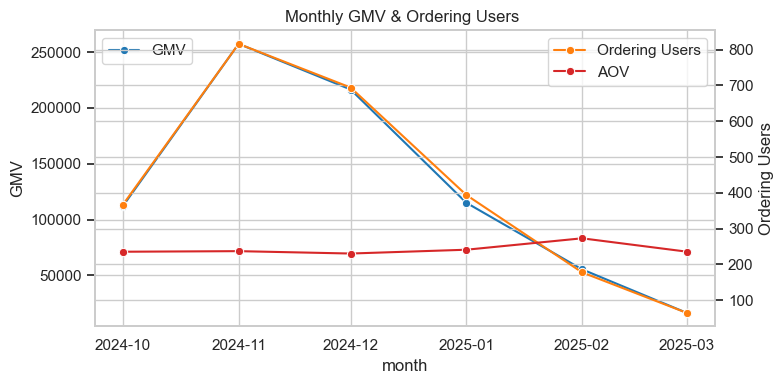

In [17]:
# 1) P3：GMV / ordering users / AOV 月度趋势
fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
sns.lineplot(
    data=trend_panel,
    x="month", y="gmv", marker="o", color="tab:blue", label="GMV",
    ax=ax1,
)
sns.lineplot(
    data=trend_panel,
    x="month", y="ordering_users", marker="o", color="tab:orange", label="Ordering Users",
    ax=ax2,
)
sns.lineplot(
    data=trend_panel,
    x="month", y="aov", marker="o", color="tab:red", label="AOV",
    ax=ax2,
)
ax1.set_ylabel("GMV")
ax2.set_ylabel("Ordering Users")
ax1.set_title("Monthly GMV & Ordering Users ")
ax1.legend(loc="upper left")
plt.tight_layout()
plt.show()

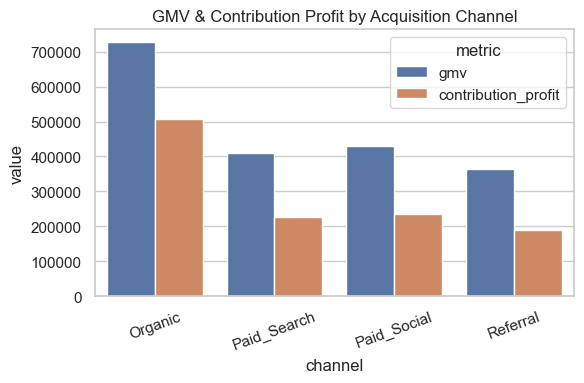

In [16]:
# 2) P6：渠道诊断 – GMV & contribution profit by channel
plt.figure(figsize=(6, 4))
channel_plot = channel_summary.copy()
channel_plot["channel"] = channel_plot["acquisition_channel"]
channel_plot_melt = channel_plot.melt(
    id_vars="channel",
    value_vars=["gmv", "contribution_profit"],
    var_name="metric",
    value_name="value",
)
sns.barplot(
    data=channel_plot_melt,
    x="channel", y="value", hue="metric"
)
plt.title("GMV & Contribution Profit by Acquisition Channel")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

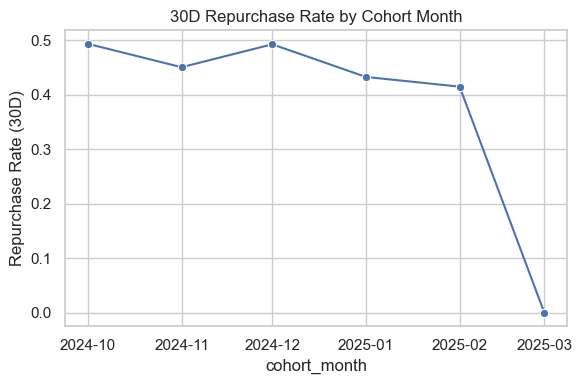

In [15]:
# 3) P5/N3：cohort 30D 复购率曲线
plt.figure(figsize=(6, 4))
sns.lineplot(
    data=cohort_summary,
    x="cohort_month", y="repurchase_rate_30d", marker="o"
)
plt.title("30D Repurchase Rate by Cohort Month")
plt.ylabel("Repurchase Rate (30D)")
plt.tight_layout()
plt.show()

In [18]:
# 1) dim_campaign -> 月度 Marketing Cost
# 简化口径：把整个 campaign 成本摊到 start_time 所在的月
dim_campaign["month"] = dim_campaign["start_time"].dt.to_period("M").dt.to_timestamp()
campaign_month = (
    dim_campaign
    .groupby("month", as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "marketing_cost"})
)
# 2) 与 gmv_profit_month 合并
# gmv_profit_month: month, gmv_paid, cogs, gross_profit, gross_margin_rate
profit_bridge_month = gmv_profit_month.merge(
    campaign_month, on="month", how="left"
)
# 没有 campaign 的月份营销费用记为 0
profit_bridge_month["marketing_cost"] = profit_bridge_month["marketing_cost"].fillna(0.0)
# 3) 假设履约成本按 GMV 一定费率
FULFILLMENT_RATE = 0.05  # 可以根据业务故事微调
profit_bridge_month["fulfillment_cost"] = (
    profit_bridge_month["gmv_paid"] * FULFILLMENT_RATE
)

fixed_cost_monthly = 10000
# 4) 经营利润（Operating Profit）
profit_bridge_month["operating_profit"] = (
    profit_bridge_month["gross_profit"]
    - profit_bridge_month["fulfillment_cost"]
    - fixed_cost_monthly
    - profit_bridge_month["marketing_cost"]
)
print(profit_bridge_month)


       month   gmv_paid       cogs  gross_profit  gross_margin_rate  \
0 2024-10-01  112109.64   82535.28      29574.36           0.263799   
1 2024-11-01  257317.24  190202.54      67114.70           0.260825   
2 2024-12-01  216447.66  160635.53      55812.13           0.257855   
3 2025-01-01  115027.20   85429.44      29597.76           0.257311   
4 2025-02-01   55425.10   40961.72      14463.38           0.260954   
5 2025-03-01   16506.48   12000.69       4505.79           0.272971   

   marketing_cost  fulfillment_cost  operating_profit  
0    39360.745443          5605.482     -25391.867443  
1    49361.711595         12865.862      -5112.873595  
2    73347.701784         10822.383     -38357.954784  
3        0.000000          5751.360      13846.400000  
4    38191.715598          2771.255     -36499.590598  
5        0.000000           825.324      -6319.534000  


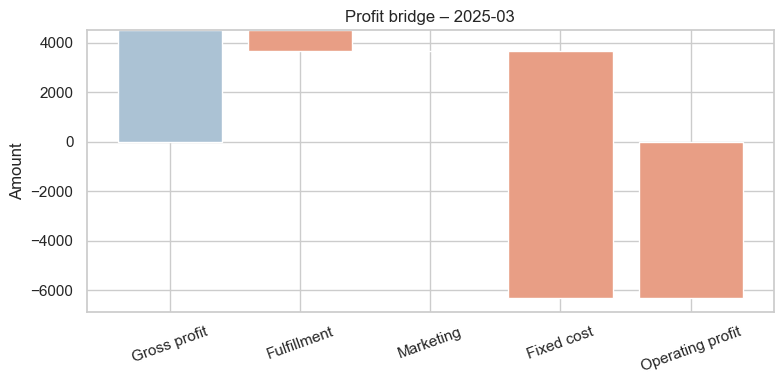

In [19]:
import matplotlib.pyplot as plt
row = profit_bridge_month.iloc[-1]  # 例如最近一个月
fixed_cost_monthly = 10000
steps = ["Gross profit", "Fulfillment", "Marketing", "Fixed cost", "Operating profit"]
values = [
    row["gross_profit"],
    -row["fulfillment_cost"],
    -row["marketing_cost"],
    -fixed_cost_monthly,
    row["operating_profit"],
]

# 计算每个柱子的起始位置（累积和）
starts = [0]
for d in values[:-1]:
    starts.append(starts[-1] + d)

# 绘图
plt.figure(figsize=(8, 4))
for i, (s, d) in enumerate(zip(starts, values[:-1])):
    color = "#abc2d4" if d >= 0 else "#e89e85"
    plt.bar(i, d, bottom=s, color=color)
    
# 绘制第五列（Operating profit）：从0开始，高度为运营利润
plt.bar(4, row["operating_profit"], bottom=0, 
        color = "#abc2d4" if row["operating_profit"] >= 0 else "#e89e85")  # 用不同颜色区分

plt.xticks(range(len(steps)), steps, rotation=20)
plt.ylabel("Amount")
plt.title(f"Profit bridge – {row['month'].strftime('%Y-%m')}")
plt.tight_layout()
plt.show()

In [9]:
####p4 单位经济

# ============================ 指标1: Contribution per order ============================
avg_contribution_per_order = order_user_item['contribution_profit'].mean()
print(f"\n[指标] 平均单订单贡献利润 (Contribution per order): {avg_contribution_per_order:.2f}")


[指标] 平均单订单贡献利润 (Contribution per order): 39.01


In [10]:
# ============================ 指标2: Simple LTV proxy (90D gross profit per new user) ============================
# 使用 fact_order_enriched 已有 first_order_time 和 order_time
# 需要先确保 fact_order_enriched 包含每个订单的贡献利润（合并 order_user_item）
ltv_orders = fact_order_enriched.merge(
    order_user_item[['order_id', 'contribution_profit', 'gross_profit']],
    on='order_id',
    how='left'
)

# 过滤未退款订单
ltv_orders = ltv_orders[ltv_orders['is_refunded'] == 0].copy()

# 计算每个用户首单后90天内的订单
ltv_orders['days_since_first'] = (ltv_orders['order_time'] - ltv_orders['first_order_time']).dt.days
ltv_90d = ltv_orders[ltv_orders['days_since_first'] <= 90].copy()

# 按用户聚合：计算90天内贡献利润总和（或gross profit）
user_ltv = ltv_90d.groupby('user_id').agg(
    ltv_contribution=('contribution_profit', 'sum'),
    ltv_gross=('gross_profit', 'sum')
).reset_index()

# 添加用户注册月份（首次下单月份）
user_first = fact_order_enriched[['user_id', 'first_order_time']].drop_duplicates()
user_ltv = user_ltv.merge(user_first, on='user_id', how='left')
user_ltv['cohort_month'] = user_ltv['first_order_time'].dt.to_period('M').dt.to_timestamp()

# 按群组计算平均LTV proxy（90天贡献利润）
cohort_ltv = user_ltv.groupby('cohort_month').agg(
    new_users=('user_id', 'count'),
    avg_ltv_contribution=('ltv_contribution', 'mean'),
    avg_ltv_gross=('ltv_gross', 'mean')
).reset_index()

print("\n[指标] 各群组90天LTV proxy (平均贡献利润 per new user):")
print(cohort_ltv)



[指标] 各群组90天LTV proxy (平均贡献利润 per new user):
  cohort_month  new_users  avg_ltv_contribution  avg_ltv_gross
0   2024-10-01        367             76.237510     142.152861
1   2024-11-01        684             71.914287     140.298231
2   2024-12-01        459             68.379648     131.304946
3   2025-01-01        185             71.082477     140.971946
4   2025-02-01         41             64.448927     132.899512
5   2025-03-01          3            115.430914     207.780000


In [11]:
# ============================ 指标3: Payback period (LTV/CAC简化) ============================
# 计算每个渠道的CAC（营销成本 / 该渠道用户数）
channel_stats['cac'] = channel_stats['marketing_cost'] / channel_stats['ordering_users'].replace(0, np.nan)

# 需要每个渠道的90天LTV proxy平均值
# 先获取每个用户所属渠道
user_channel = dim_user[['user_id', 'acquisition_channel']]
user_ltv = user_ltv.merge(user_channel, on='user_id', how='left')

# 按渠道计算平均90天贡献利润
channel_ltv = user_ltv.groupby('acquisition_channel').agg(
    avg_ltv_90d=('ltv_contribution', 'mean')
).reset_index()

# 合并渠道信息
channel_payback = channel_stats.merge(channel_ltv, on='acquisition_channel', how='left')
# 计算回本期（月）：CAC / (LTV_90d / 3)  （因为90天约3个月）
channel_payback['payback_months'] = channel_payback['cac'] / (channel_payback['avg_ltv_90d'] / 3)

print("\n[指标] 各渠道CAC、90天LTV及回本期（月）:")
print(channel_payback[['acquisition_channel', 'cac', 'avg_ltv_90d', 'payback_months']].round(2))

# 可选：整体平均回本期
overall_cac = channel_stats['marketing_cost'].sum() / channel_stats['ordering_users'].sum()
overall_ltv = user_ltv['ltv_contribution'].mean()
overall_payback = overall_cac / (overall_ltv / 3)
print(f"\n[指标] 整体平均回本期（月）: {overall_payback:.2f}")


[指标] 各渠道CAC、90天LTV及回本期（月）:
  acquisition_channel     cac  avg_ltv_90d  payback_months
0             Organic    0.00       115.26            0.00
1         Paid_Search  153.46        53.09            8.67
2         Paid_Social  194.23        43.02           13.55
3            Referral  221.80        35.04           18.99

[指标] 整体平均回本期（月）: 4.82


In [12]:
# =========================================================
# 补充：注册 cohort → 首购转化漏斗
# =========================================================

# 1. 计算每个用户的首购时间（已存在于 user_first_order）
# user_first_order 包含 user_id 和 first_order_time

# 2. 合并 dim_user 获取注册时间
user_cohort = dim_user[['user_id', 'signup_time']].merge(
    user_first_order, on='user_id', how='left'
)

# 3. 提取注册月份 cohort
user_cohort['signup_cohort'] = user_cohort['signup_time'].dt.to_period('M').dt.to_timestamp()

# 4. 标记是否有首购
user_cohort['has_first_order'] = user_cohort['first_order_time'].notna().astype(int)

# 5. 按注册月份统计
cohort_funnel = user_cohort.groupby('signup_cohort').agg(
    signup_users=('user_id', 'count'),
    first_order_users=('has_first_order', 'sum')
).reset_index()
cohort_funnel['signup_to_first_rate'] = cohort_funnel['first_order_users'] / cohort_funnel['signup_users']

print("\n[漏斗] 注册 → 首购转化率 by cohort:")
print(cohort_funnel)


[漏斗] 注册 → 首购转化率 by cohort:
  signup_cohort  signup_users  first_order_users  signup_to_first_rate
0    2024-10-01          1326                464              0.349925
1    2024-11-01          1951                694              0.355715
2    2024-12-01          1224                408              0.333333
3    2025-01-01           434                149              0.343318
4    2025-02-01            65                 24              0.369231


In [13]:
# =========================================================
# Orders/user split: new vs existing
# =========================================================

# 过滤退款订单（可选，可根据分析需求决定是否过滤）
orders_valid = fact_order_enriched[fact_order_enriched['is_refunded'] == 0].copy()

# 按月、新老用户分组聚合
new_vs_existing = orders_valid.groupby(['month', 'is_new_ordering_user']).agg(
    orders=('order_id', 'count'),
    users=('user_id', 'nunique'),
    gmv=('pay_amount', 'sum')
).reset_index()

# 计算人均订单数
new_vs_existing['orders_per_user'] = new_vs_existing['orders'] / new_vs_existing['users']

# 将新老两列拆分为独立列，方便对比
new_vs_existing_pivot = new_vs_existing.pivot(
    index='month',
    columns='is_new_ordering_user',
    values=['orders', 'users', 'gmv', 'orders_per_user']
)
# 重命名列
new_vs_existing_pivot.columns = [
    f"{col[0]}_{'new' if col[1]==1 else 'existing'}" for col in new_vs_existing_pivot.columns
]
new_vs_existing_pivot = new_vs_existing_pivot.reset_index()

print("\n[New vs Existing] 各月新老用户订单、用户数、GMV及人均订单数:")
print(new_vs_existing_pivot.round(2))

# 可选：计算新老用户订单占比
total_orders = new_vs_existing.groupby('month')['orders'].sum().rename('total_orders')
new_vs_existing = new_vs_existing.merge(total_orders, on='month')
new_vs_existing['order_share'] = new_vs_existing['orders'] / new_vs_existing['total_orders']

print("\n[New vs Existing] 各月新老用户订单占比:")
print(new_vs_existing.pivot(index='month', columns='is_new_ordering_user', values='order_share').round(3))


[New vs Existing] 各月新老用户订单、用户数、GMV及人均订单数:
       month  orders_existing  orders_new  users_existing  users_new  \
0 2024-10-01              NaN       476.0             NaN      367.0   
1 2024-11-01            153.0       932.0           132.0      684.0   
2 2024-12-01            272.0       667.0           235.0      459.0   
3 2025-01-01            229.0       248.0           209.0      185.0   
4 2025-02-01            144.0        59.0           137.0       41.0   
5 2025-03-01             67.0         3.0            62.0        3.0   

   gmv_existing    gmv_new  orders_per_user_existing  orders_per_user_new  
0           NaN  112109.64                       NaN                 1.30  
1      36149.46  221167.78                      1.16                 1.36  
2      62813.16  153634.50                      1.16                 1.45  
3      53185.42   61841.78                      1.10                 1.34  
4      40757.59   14667.51                      1.05                 1.4

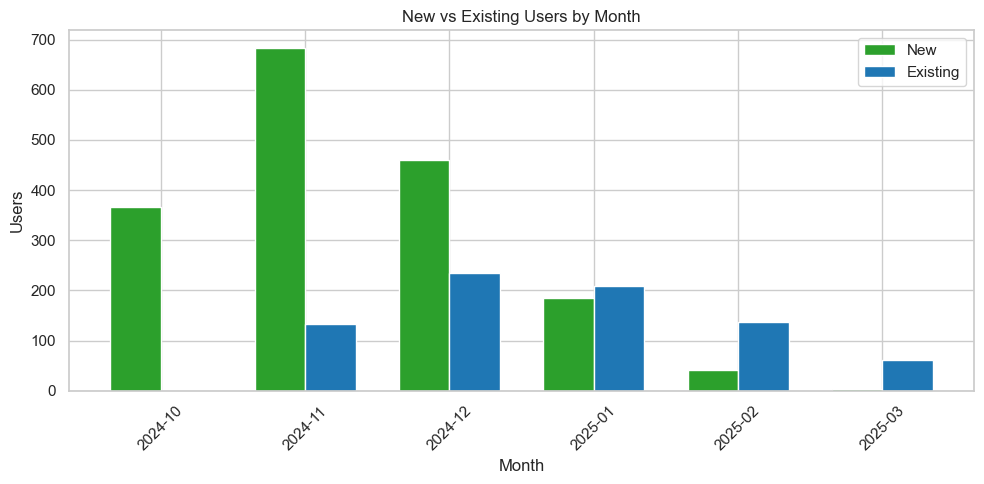

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# 选择要绘制的指标  单数量的对比
metric = 'users'  # 可替换为 'users', 'gmv'
new_col = f'{metric}_new'
exist_col = f'{metric}_existing'

plt.figure(figsize=(10, 5))
x = np.arange(len(new_vs_existing_pivot))
width = 0.35

plt.bar(x - width/2, new_vs_existing_pivot[new_col], width, label='New', color='#2ca02c')
plt.bar(x + width/2, new_vs_existing_pivot[exist_col], width, label='Existing', color='#1f77b4')
plt.xlabel('Month')
plt.ylabel(metric.capitalize())
plt.title(f'New vs Existing {metric.capitalize()} by Month')
plt.xticks(x, new_vs_existing_pivot['month'].dt.strftime('%Y-%m'), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

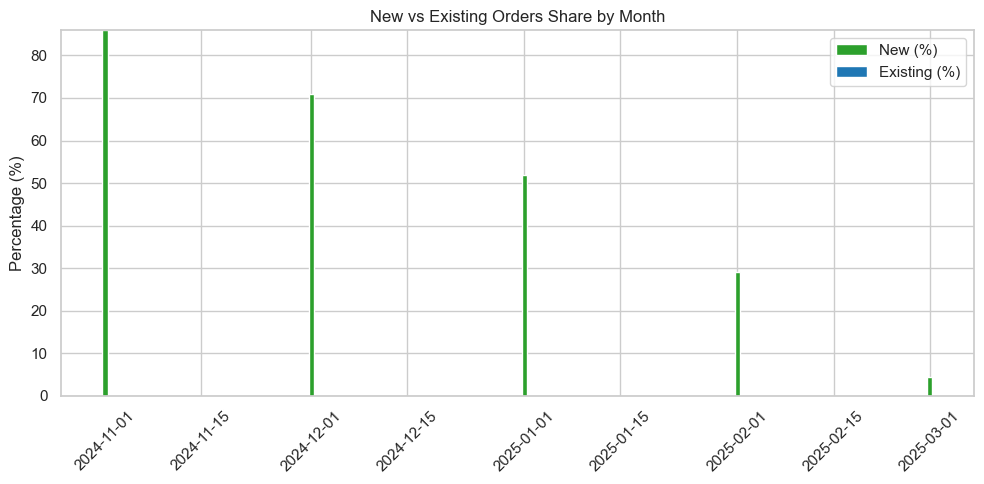

In [22]:
new_vs_existing_pivot['orders_new_pct'] = new_vs_existing_pivot['orders_new'] / new_vs_existing_pivot['orders_total'] * 100
new_vs_existing_pivot['orders_existing_pct'] = 100 - new_vs_existing_pivot['orders_new_pct']

plt.figure(figsize=(10, 5))
plt.bar(new_vs_existing_pivot['month'], new_vs_existing_pivot['orders_new_pct'], label='New (%)', color='#2ca02c')
plt.bar(new_vs_existing_pivot['month'], new_vs_existing_pivot['orders_existing_pct'], 
        bottom=new_vs_existing_pivot['orders_new_pct'], label='Existing (%)', color='#1f77b4')
plt.ylabel('Percentage (%)')
plt.title('New vs Existing Orders Share by Month')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

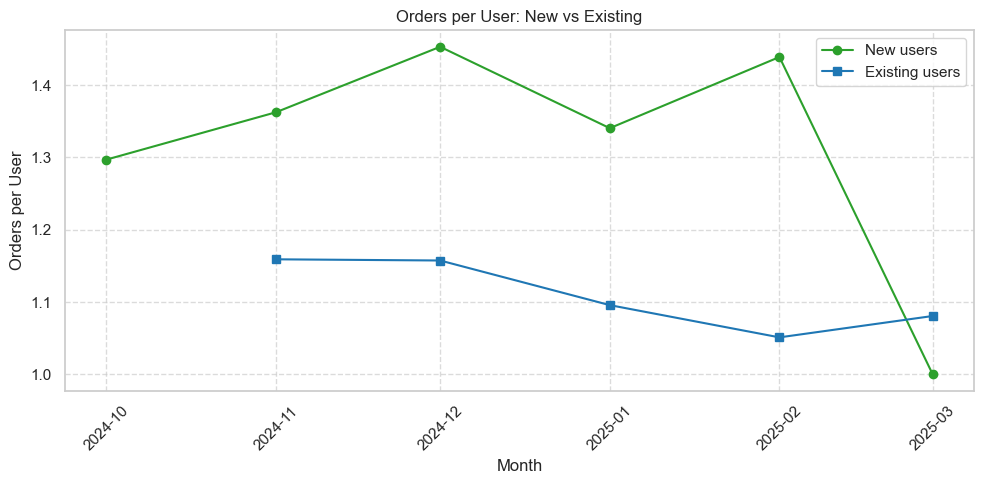

In [23]:
plt.figure(figsize=(10, 5))
plt.plot(new_vs_existing_pivot['month'], new_vs_existing_pivot['orders_per_user_new'], 
         marker='o', label='New users', color='#2ca02c')
plt.plot(new_vs_existing_pivot['month'], new_vs_existing_pivot['orders_per_user_existing'], 
         marker='s', label='Existing users', color='#1f77b4')
plt.xlabel('Month')
plt.ylabel('Orders per User')
plt.title('Orders per User: New vs Existing')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

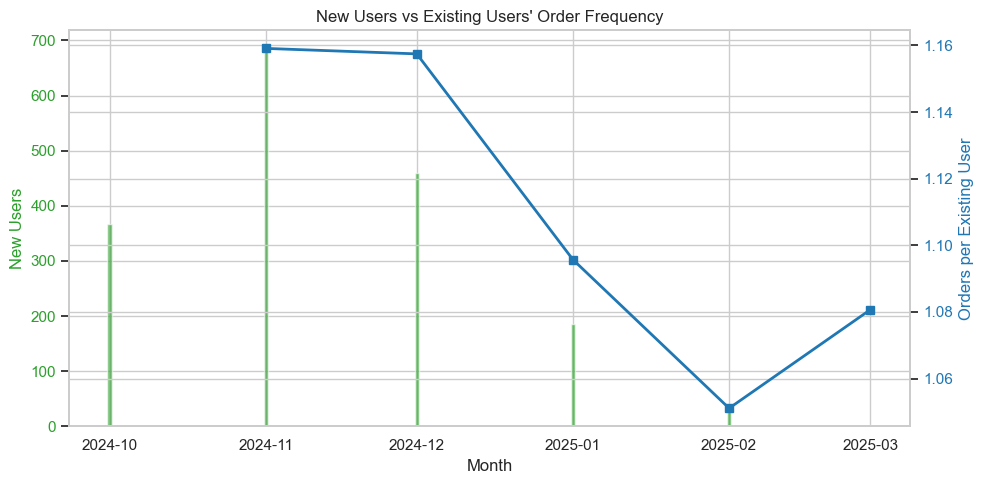

In [24]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# 柱状图：新用户数
color = '#2ca02c'
ax1.set_xlabel('Month')
ax1.set_ylabel('New Users', color=color)
ax1.bar(new_vs_existing_pivot['month'], new_vs_existing_pivot['users_new'], color=color, alpha=0.6, label='New Users')
ax1.tick_params(axis='y', labelcolor=color)

# 双轴：老用户人均订单数
ax2 = ax1.twinx()
color = '#1f77b4'
ax2.set_ylabel('Orders per Existing User', color=color)
ax2.plot(new_vs_existing_pivot['month'], new_vs_existing_pivot['orders_per_user_existing'], 
         color=color, marker='s', linestyle='-', linewidth=2, label='Orders/Existing User')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('New Users vs Existing Users\' Order Frequency')
fig.tight_layout()
plt.show()

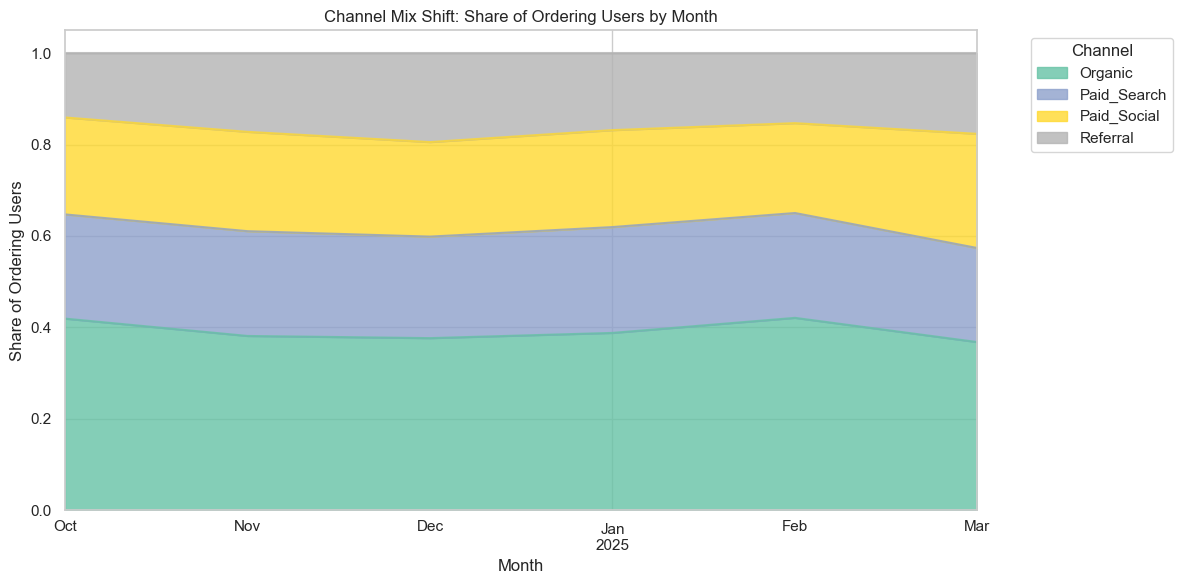

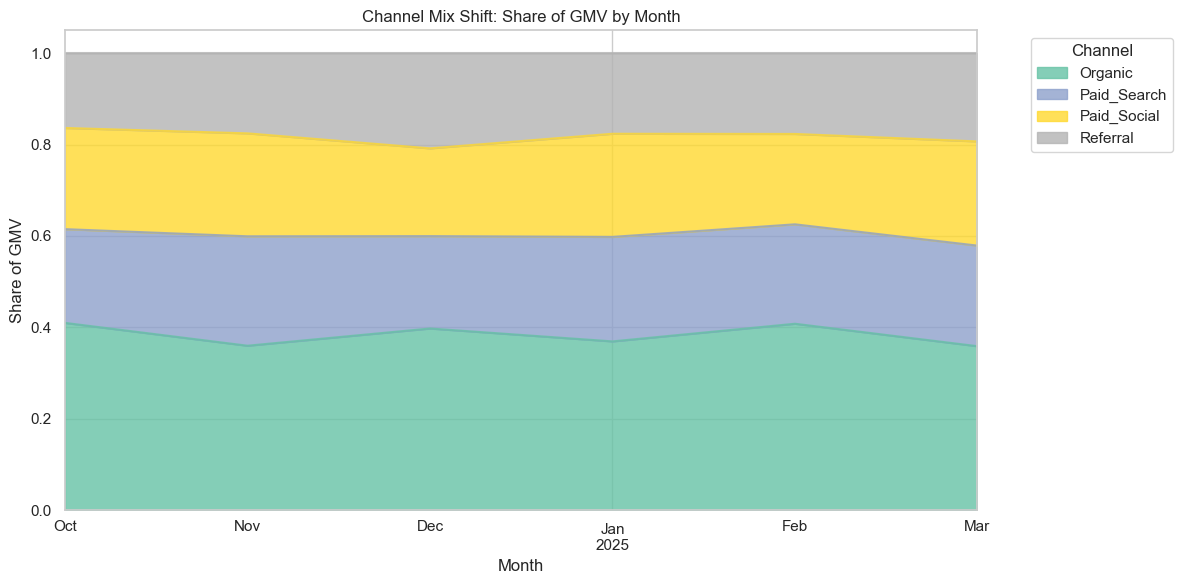

In [29]:
# =========================================================
# 1. Channel mix shift (share of ordering users / GMV)
# =========================================================

# 确保 order_user_item 有 month 和 acquisition_channel 字段
if 'month' not in order_user_item.columns:
    order_user_item['month'] = order_user_item['order_time'].dt.to_period('M').dt.to_timestamp()

# 按月、渠道聚合
channel_mix = order_user_item.groupby(['month', 'acquisition_channel']).agg(
    ordering_users=('user_id', 'nunique'),
    gmv=('pay_amount', 'sum')
).reset_index()

# 计算每月总量
monthly_totals = channel_mix.groupby('month')[['ordering_users', 'gmv']].sum().reset_index()
monthly_totals.columns = ['month', 'total_users', 'total_gmv']

# 合并并计算占比
channel_mix = channel_mix.merge(monthly_totals, on='month')
channel_mix['user_share'] = channel_mix['ordering_users'] / channel_mix['total_users']
channel_mix['gmv_share'] = channel_mix['gmv'] / channel_mix['total_gmv']

# 绘制堆叠面积图（以用户占比为例）
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# 数据透视：行为月份，列为渠道，值为占比
user_share_pivot = channel_mix.pivot(index='month', columns='acquisition_channel', values='user_share').fillna(0)
user_share_pivot.plot.area(stacked=True, alpha=0.8, colormap='Set2', ax=plt.gca())
plt.title('Channel Mix Shift: Share of Ordering Users by Month')
plt.ylabel('Share of Ordering Users')
plt.xlabel('Month')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 如需 GMV 占比，类似处理
gmv_share_pivot = channel_mix.pivot(index='month', columns='acquisition_channel', values='gmv_share').fillna(0)
gmv_share_pivot.plot.area(stacked=True, alpha=0.8, colormap='Set2', figsize=(12,6))
plt.title('Channel Mix Shift: Share of GMV by Month')
plt.ylabel('Share of GMV')
plt.xlabel('Month')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

0      0.000000
1    153.462967
2    194.230790
3    221.800377
Name: cac_per_user, dtype: float64
0    115.259820
1     53.091103
2     43.017406
3     35.035050
Name: avg_ltv_90d, dtype: float64
0    671
1    385
2    374
3    309
Name: ordering_users, dtype: int64


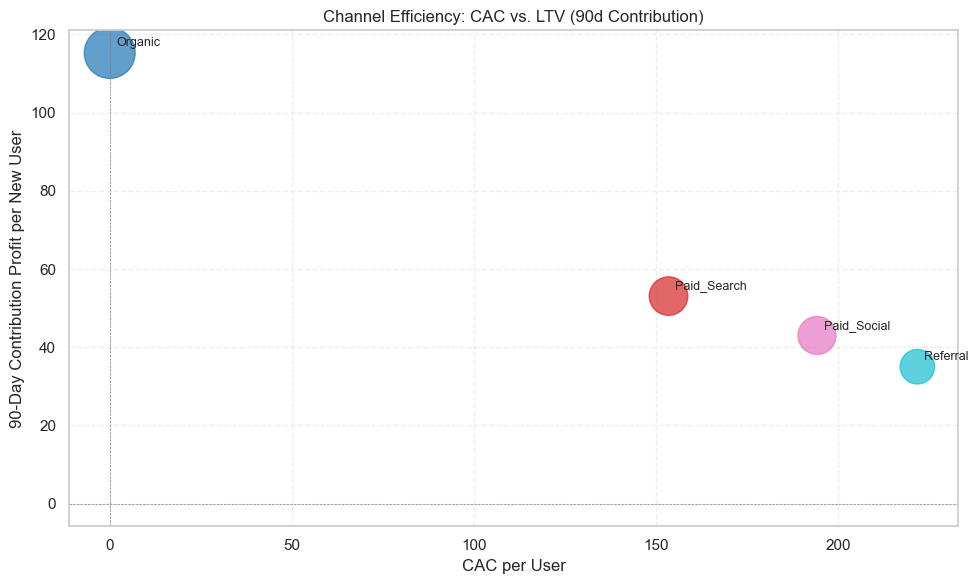

In [31]:
# =========================================================
# 2. CAC vs Contribution Profit per New User (Scatter)
# =========================================================

# 确保已有渠道级的 90 天 LTV 数据（来自之前计算的 channel_ltv）
# 如果未计算，需重新计算（使用 user_ltv 和 user_channel）
if 'avg_ltv_90d' not in channel_summary.columns:
    # 计算用户级 LTV（需确保 user_ltv 存在）
    if 'user_ltv' not in locals():
        # 重新计算 user_ltv（简化版：使用 ltv_contribution）
        # 从 fact_order_enriched 和 order_user_item 重新计算
        ltv_orders = fact_order_enriched.merge(
            order_user_item[['order_id', 'contribution_profit']], on='order_id', how='left'
        )
        ltv_orders = ltv_orders[ltv_orders['is_refunded'] == 0].copy()
        ltv_orders['days_since_first'] = (ltv_orders['order_time'] - ltv_orders['first_order_time']).dt.days
        ltv_90d = ltv_orders[ltv_orders['days_since_first'] <= 90].copy()
        user_ltv = ltv_90d.groupby('user_id').agg(ltv_contribution=('contribution_profit', 'sum')).reset_index()
        user_ltv = user_ltv.merge(dim_user[['user_id', 'acquisition_channel']], on='user_id')
    
    # 按渠道计算平均 90 天贡献利润
    channel_ltv = user_ltv.groupby('acquisition_channel')['ltv_contribution'].mean().reset_index()
    channel_ltv.columns = ['acquisition_channel', 'avg_ltv_90d']
    
    # 合并到 channel_summary
    channel_summary = channel_summary.merge(channel_ltv, on='acquisition_channel', how='left')

print(channel_summary['cac_per_user'])
print(channel_summary['avg_ltv_90d'])
print(channel_summary['ordering_users'])
    
# 绘制散点图
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=channel_summary['cac_per_user'],
    y=channel_summary['avg_ltv_90d'],
    s=channel_summary['ordering_users'] * 2,  # 气泡大小缩放，可根据需要调整
    c=range(len(channel_summary)),  # 用不同颜色标识渠道
    cmap='tab10',
    alpha=0.7
)
# 添加渠道标签
for i, row in channel_summary.iterrows():
    plt.annotate(row['acquisition_channel'], 
                 (row['cac_per_user'], row['avg_ltv_90d']),
                 xytext=(5,5), textcoords='offset points', fontsize=9)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='gray', linestyle='--', linewidth=0.5)
plt.xlabel('CAC per User')
plt.ylabel('90-Day Contribution Profit per New User')
plt.title('Channel Efficiency: CAC vs. LTV (90d Contribution)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


[渠道漏斗效率] CVR 与 30天复购率:
  acquisition_channel  total_users  first_order_users    cvr  \
0             Organic         1723                671  0.389   
1         Paid_Search         1277                385  0.301   
2         Paid_Social         1251                374  0.299   
3            Referral          749                309  0.413   

   repurchase_rate_30d  
0                0.443  
1                0.447  
2                0.422  
3                0.456  
  acquisition_channel  total_users  first_order_users       cvr  \
0             Organic         1723                671  0.389437   
1         Paid_Search         1277                385  0.301488   
2         Paid_Social         1251                374  0.298961   
3            Referral          749                309  0.412550   

   repurchase_rate_30d  
0             0.442623  
1             0.446753  
2             0.422460  
3             0.456311  


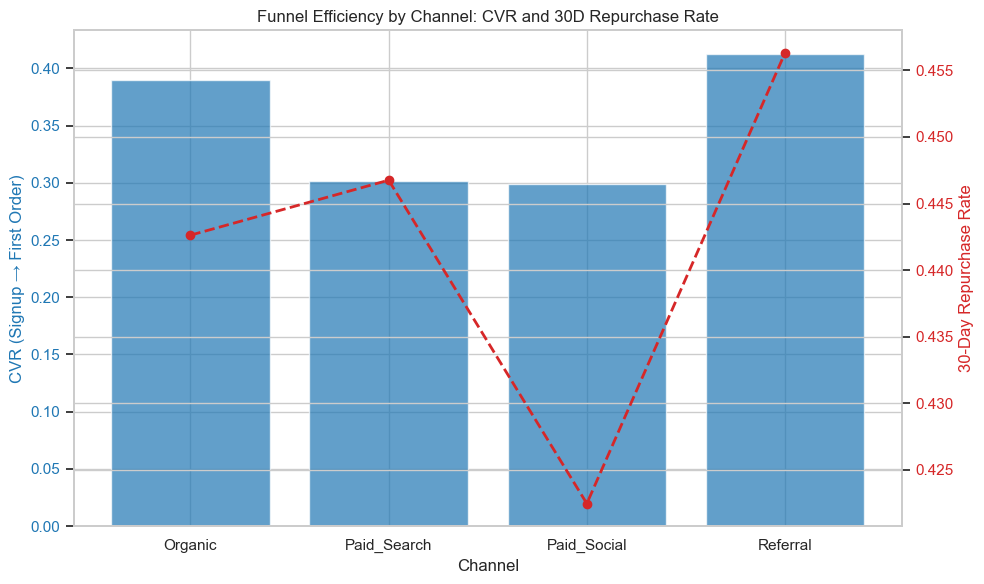

In [32]:
# =========================================================
# 3. Funnel Efficiency by Channel (CVR & 30D Retention)
# =========================================================

# 3.1 注册 → 首购转化率（CVR）
# 获取所有注册用户及其渠道
all_users = dim_user[['user_id', 'acquisition_channel', 'signup_time']].copy()
# 获取有首购的用户及其首购时间（来自 user_first_order）
user_first = user_first_order.rename(columns={'order_time': 'first_order_time'})
user_cvr = all_users.merge(user_first, on='user_id', how='left')
user_cvr['has_first_order'] = user_cvr['first_order_time'].notna().astype(int)

# 按渠道计算 CVR
cvr_by_channel = user_cvr.groupby('acquisition_channel').agg(
    total_users=('user_id', 'count'),
    first_order_users=('has_first_order', 'sum')
).reset_index()
cvr_by_channel['cvr'] = cvr_by_channel['first_order_users'] / cvr_by_channel['total_users']

# 3.2 30 天复购率（按渠道）
# 获取每个用户的首购时间（已存在 user_first）
# 从 order_user_item 获取所有订单（排除首购当天？）
# 需要每个用户的订单时间（非首购）是否在首购后30天内
repurchase_data = fact_order_enriched.merge(
    order_user_item[['order_id', 'contribution_profit']], on='order_id', how='left'
)
repurchase_data = repurchase_data[repurchase_data['is_refunded'] == 0].copy()
repurchase_data['days_since_first'] = (repurchase_data['order_time'] - repurchase_data['first_order_time']).dt.days

# 标记每个用户在首购后30天内是否有复购
repurchase_flag = repurchase_data[
    (repurchase_data['days_since_first'] > 0) & (repurchase_data['days_since_first'] <= 30)
].groupby('user_id').size().reset_index(name='repurchased_30d')
repurchase_flag['repurchased_30d'] = 1  # 有复购即为1

# 合并用户首购信息和渠道
user_repurchase = user_first.merge(dim_user[['user_id', 'acquisition_channel']], on='user_id', how='left')
user_repurchase = user_repurchase.merge(repurchase_flag, on='user_id', how='left')
user_repurchase['repurchased_30d'] = user_repurchase['repurchased_30d'].fillna(0).astype(int)

# 按渠道计算30天复购率
retention_by_channel = user_repurchase.groupby('acquisition_channel').agg(
    first_order_users=('user_id', 'count'),
    repurchase_users=('repurchased_30d', 'sum')
).reset_index()
retention_by_channel['repurchase_rate_30d'] = retention_by_channel['repurchase_users'] / retention_by_channel['first_order_users']

# 合并 CVR 和复购率
funnel_efficiency = cvr_by_channel.merge(
    retention_by_channel[['acquisition_channel', 'repurchase_rate_30d']],
    on='acquisition_channel', how='left'
)

print("\n[渠道漏斗效率] CVR 与 30天复购率:")
print(funnel_efficiency.round(3))

print(funnel_efficiency)

# 绘制双轴图：柱状图表示 CVR，折线图表示复购率
fig, ax1 = plt.subplots(figsize=(10, 6))

# 柱状图：CVR
x = funnel_efficiency['acquisition_channel']
color = 'tab:blue'
ax1.set_xlabel('Channel')
ax1.set_ylabel('CVR (Signup → First Order)', color=color)
bars = ax1.bar(x, funnel_efficiency['cvr'], color=color, alpha=0.7, label='CVR')
ax1.tick_params(axis='y', labelcolor=color)

# 双轴：复购率
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('30-Day Repurchase Rate', color=color)
ax2.plot(x, funnel_efficiency['repurchase_rate_30d'], color=color, marker='o', linestyle='--', linewidth=2, label='Repurchase Rate')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Funnel Efficiency by Channel: CVR and 30D Repurchase Rate')
fig.tight_layout()
plt.show()

In [33]:
# =========================================================
# 品类价格带分析：GMV & gross margin, 折扣分布, 履约成本
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图样式
sns.set(style="whitegrid")

# 1. 数据准备：合并订单行与商品信息，过滤退款订单
order_lines = bridge_order_item.merge(
    dim_item[['item_id', 'category', 'price_band']], on='item_id', how='left'
)
order_lines = order_lines.merge(
    fact_order[['order_id', 'pay_amount', 'discount_amount', 'delivery_type', 'is_refunded']],
    on='order_id', how='left'
)
# 只考虑有效订单（未退款）
order_lines = order_lines[order_lines['is_refunded'] == 0].copy()

# 计算每行的 GMV 和 COGS
order_lines['gmv_line'] = order_lines['item_price'] * order_lines['quantity']
order_lines['cogs_line'] = order_lines['item_cost'] * order_lines['quantity']

# 计算每个订单的总 GMV（用于后续分摊）
order_total_gmv = order_lines.groupby('order_id')['gmv_line'].sum().rename('order_total_gmv')
order_lines = order_lines.merge(order_total_gmv, on='order_id', how='left')

# 分摊订单折扣到每个订单行
order_lines['discount_allocated'] = order_lines['discount_amount'] * (order_lines['gmv_line'] / order_lines['order_total_gmv'])
# 计算行的折扣率（注意：分母是行 GMV，分子是分摊折扣）
order_lines['discount_rate_line'] = order_lines['discount_allocated'] / order_lines['gmv_line']

# 分摊履约成本（按订单实付金额的5%计算）
FULFILLMENT_RATE = 0.05
order_lines['fulfillment_allocated'] = (order_lines['pay_amount'] * FULFILLMENT_RATE) * (order_lines['gmv_line'] / order_lines['order_total_gmv'])



[类目贡献] GMV 与毛利率:
   category        gmv       cogs  gross_profit  gross_margin
0  Beverage  190692.63  135570.98      55121.65          0.29
1      Food  181244.95  127800.35      53444.60          0.29
2     Fresh  196828.89  133716.48      63112.41          0.32
3    Retail  247527.68  174677.39      72850.29          0.29


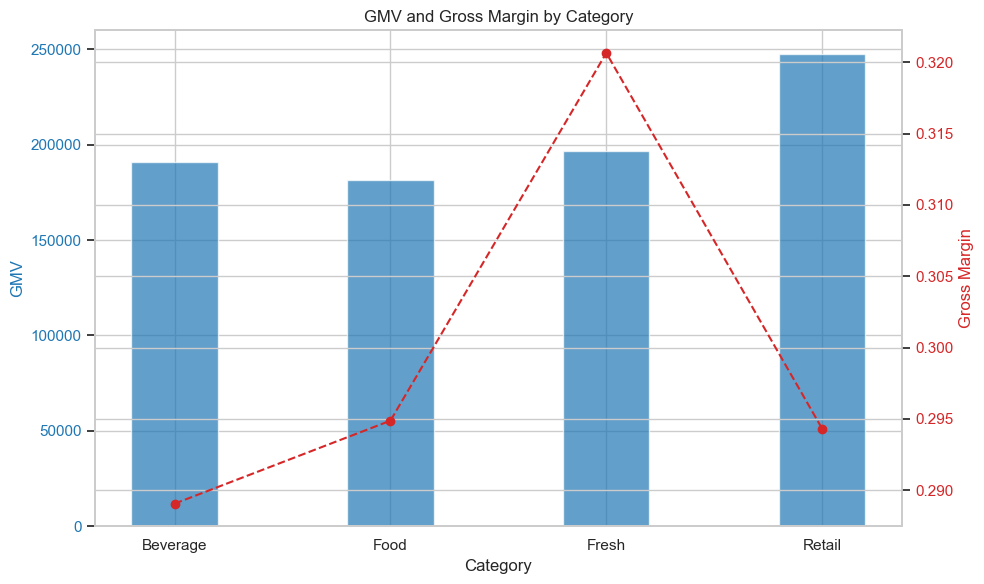

In [34]:
# =========================================================
# 1) GMV & gross margin by category（类目贡献）
# =========================================================

category_perf = order_lines.groupby('category').agg(
    gmv=('gmv_line', 'sum'),
    cogs=('cogs_line', 'sum')
).reset_index()
category_perf['gross_profit'] = category_perf['gmv'] - category_perf['cogs']
category_perf['gross_margin'] = category_perf['gross_profit'] / category_perf['gmv']

print("\n[类目贡献] GMV 与毛利率:")
print(category_perf.round(2))

# 绘制双柱状图：GMV（左轴）和毛利率（右轴）
fig, ax1 = plt.subplots(figsize=(10, 6))

x = category_perf['category']
width = 0.4
color = 'tab:blue'
ax1.bar(x, category_perf['gmv'], width, color=color, alpha=0.7, label='GMV')
ax1.set_xlabel('Category')
ax1.set_ylabel('GMV', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(x, category_perf['gross_margin'], marker='o', linestyle='--', color=color, label='Gross Margin')
ax2.set_ylabel('Gross Margin', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('GMV and Gross Margin by Category')
fig.tight_layout()
plt.show()

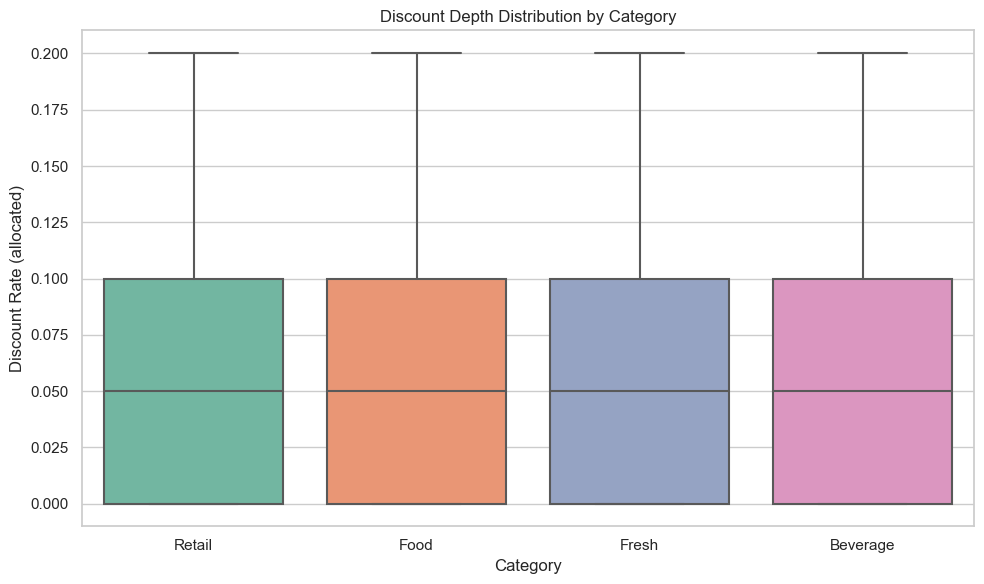

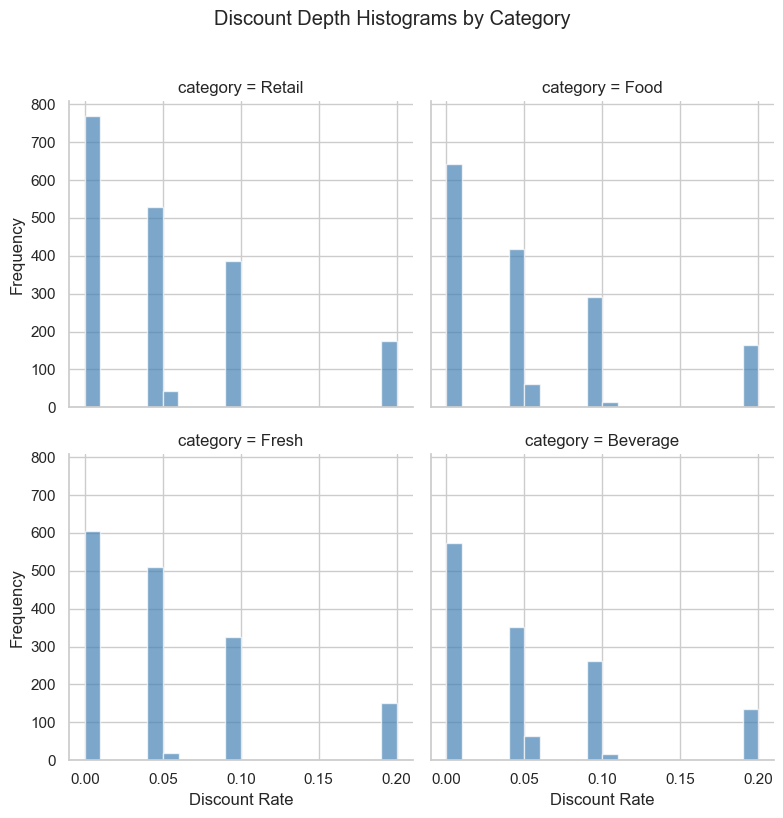

In [35]:
# =========================================================
# 2) Discount depth distribution（折扣分布）
# =========================================================

# 使用订单行级别的折扣率，按品类绘制箱线图
plt.figure(figsize=(10, 6))
sns.boxplot(data=order_lines, x='category', y='discount_rate_line', palette='Set2')
plt.title('Discount Depth Distribution by Category')
plt.ylabel('Discount Rate (allocated)')
plt.xlabel('Category')
plt.tight_layout()
plt.show()

# 也可以绘制直方图叠加
g = sns.FacetGrid(order_lines, col='category', col_wrap=2, height=4)
g.map(plt.hist, 'discount_rate_line', bins=20, alpha=0.7, color='steelblue')
g.set_axis_labels('Discount Rate', 'Frequency')
g.fig.suptitle('Discount Depth Histograms by Category', y=1.02)
plt.tight_layout()
plt.show()


[履约成本] 按主要品类和配送类型平均每订单履约成本:
  primary_category delivery_type  avg_fulfillment_per_order  order_count
0         Beverage       Instant                      12.63          417
1         Beverage       NextDay                      13.04          282
2             Food       Instant                      10.71          470
3             Food       NextDay                      11.03          313
4            Fresh       Instant                      11.37          474
5            Fresh       NextDay                      11.53          319
6           Retail       Instant                      12.80          603
7           Retail       NextDay                      11.88          372


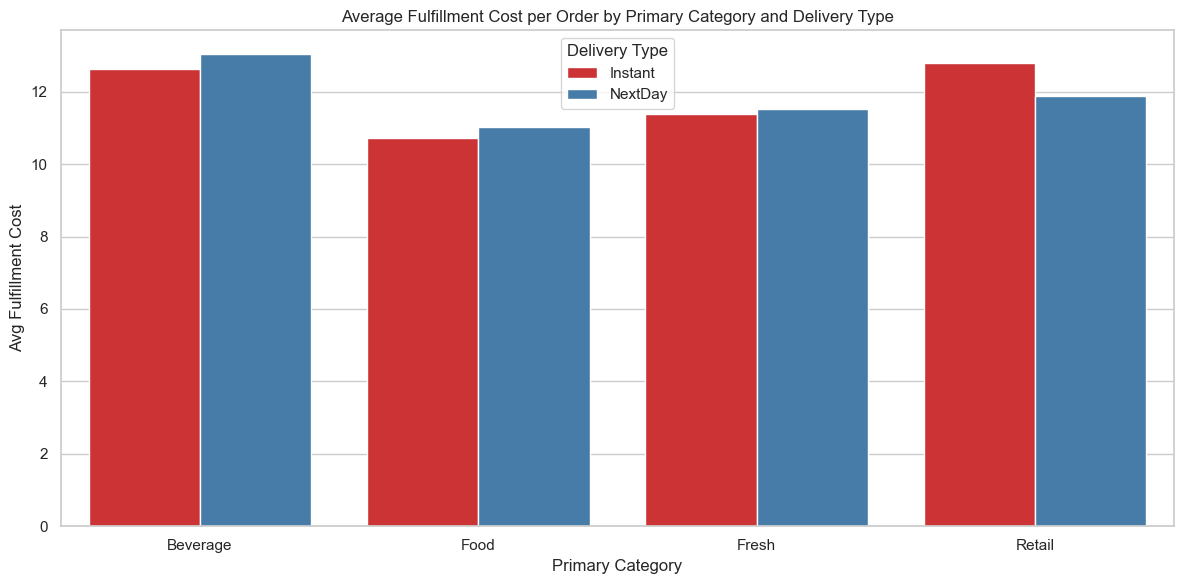

In [36]:
# =========================================================
# 3) Fulfillment cost per order by category / delivery type
# =========================================================

# 需要为每个订单确定一个主要品类（基于 GMV 最大的品类）
# 先找出每个订单各品类的总 GMV
order_category_gmv = order_lines.groupby(['order_id', 'category'])['gmv_line'].sum().reset_index()
# 找出每个订单中 GMV 最大的品类
primary_category = order_category_gmv.loc[
    order_category_gmv.groupby('order_id')['gmv_line'].idxmax()
][['order_id', 'category']].rename(columns={'category': 'primary_category'})

# 将主要品类合并到订单表
orders_with_primary = fact_order[fact_order['is_refunded'] == 0].merge(
    primary_category, on='order_id', how='left'
)
# 对于某些订单可能没有商品（理论上不会），但以防万一
orders_with_primary['primary_category'] = orders_with_primary['primary_category'].fillna('Unknown')

# 计算每个订单的履约成本
orders_with_primary['fulfillment_cost'] = orders_with_primary['pay_amount'] * FULFILLMENT_RATE

# 按主要品类和配送类型聚合
fulfillment_summary = orders_with_primary.groupby(['primary_category', 'delivery_type']).agg(
    avg_fulfillment_per_order=('fulfillment_cost', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

print("\n[履约成本] 按主要品类和配送类型平均每订单履约成本:")
print(fulfillment_summary.round(2))

# 绘制分组柱状图
plt.figure(figsize=(12, 6))
sns.barplot(
    data=fulfillment_summary,
    x='primary_category',
    y='avg_fulfillment_per_order',
    hue='delivery_type',
    palette='Set1'
)
plt.title('Average Fulfillment Cost per Order by Primary Category and Delivery Type')
plt.ylabel('Avg Fulfillment Cost')
plt.xlabel('Primary Category')
plt.legend(title='Delivery Type')
plt.tight_layout()
plt.show()

# 可选：如果希望看到更细粒度的（不按主要品类，而是按实际包含品类的订单行）
# 但此时“per order”的意义会变化，因此保留上述做法。

验证设计方案
1. 选取一个营销活动
从 dim_campaign 中选一个具有代表性的活动，例如：

类型：Discount 或 New-User

渠道：Paid_Social 或 Paid_Search

时间窗口：确保活动前后有足够的数据（例如活动持续 2-4 周，前后各 2-4 周）。

示例：假设我们选择 Paid_Social 渠道上的一个折扣活动，活动时间为 2025-01-15 至 2025-02-15。

2. 定义处理组和潜在对照组
处理组：在活动期间（2025-01-15 至 2025-02-15）通过该渠道首次下单或有过互动的用户（可根据业务定义，例如在活动期间下单的用户）。

潜在对照组：其他用户（非活动渠道、非活动期间），但需通过匹配确保与处理组在活动前特征相似。

3. 匹配方法
采用倾向得分匹配（Propensity Score Matching），匹配变量可包括：

用户注册时间（或注册月份）

活动前（例如活动前 30 天）的消费行为（如订单数、GMV）

用户城市（Tier1/Tier2/Tier3）

设备类型（iOS/Android/Web）

首次下单时间等

匹配时，对每个处理组用户，在对照组中寻找最相似的 1 个或多个用户（例如 1:3 匹配），确保两组在活动前关键指标上无显著差异。

4. 分析指标
比较处理组与对照组在活动前后的变化，常用指标：

人均 GMV（活动期间 vs 活动前）

转化率（注册到首购，或活动期间下单率）

复购率（活动后 30 天复购）

订单贡献利润（单订单贡献）

可使用 双重差分法（DiD） 思想，计算：

效果=(处理后处理−处理前处理)−(处理后对照−处理前对照)

或直接比较活动期间两组指标的差异（若匹配良好，活动前差异已消除）。

选定活动: Discount on Paid_Social, 时间: 2024-11-17 至 2024-12-05
处理组用户数: 121
对照组候选池用户数: 4879
活动前特征计算完成。
匹配后对照组用户数: 110

[DID Summary] 人均GMV和订单数:
     group  gmv_pre_mean  gmv_during_mean  orders_pre_mean  orders_during_mean
0  control        101.32            66.15             0.38                0.28
1  treated        105.14           261.81             0.39                1.16

[DID 结果] 活动对人均GMV的处理效应: 191.84
[DID 结果] 活动对人均订单数的处理效应: 0.87


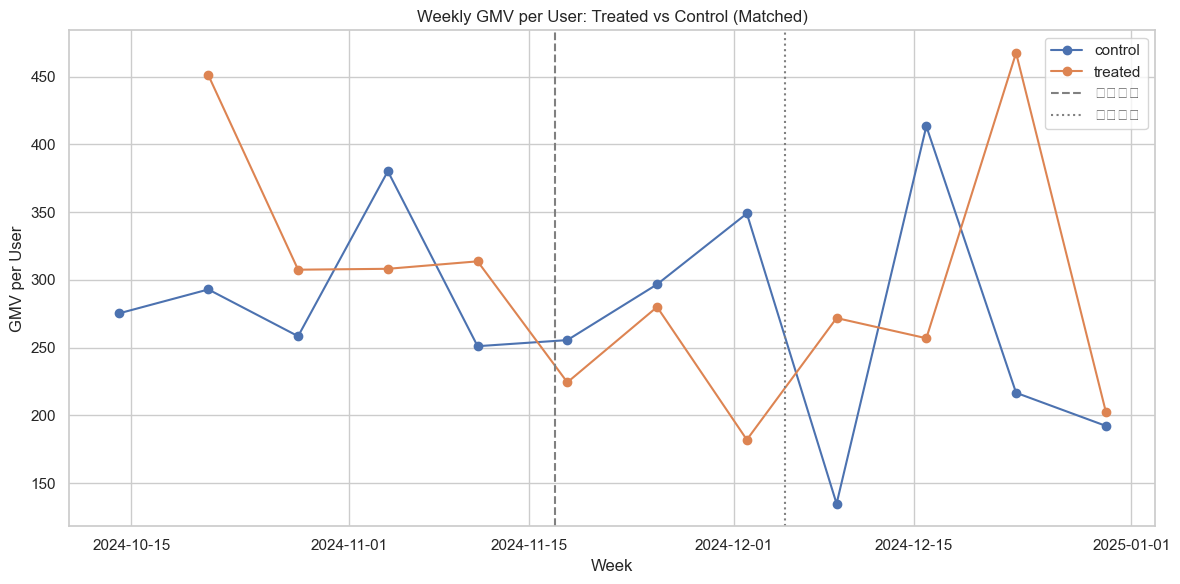

In [37]:
# =========================================================
# Campaign pre/post with matched control group
# 完整代码实现（使用倾向得分匹配 + DID）
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ------------------------------
# 1. 选择一个营销活动
# ------------------------------
# 从 dim_campaign 中选一个 Discount 类型、Paid_Social 渠道的活动
campaign = dim_campaign[(dim_campaign['type'] == 'Discount') & (dim_campaign['channel'] == 'Paid_Social')].iloc[0]
start_date = campaign['start_time']
end_date = campaign['end_time']
print(f"选定活动: {campaign['type']} on {campaign['channel']}, 时间: {start_date.date()} 至 {end_date.date()}")

# ------------------------------
# 2. 定义处理组（活动期间通过该渠道下单的用户）
# ------------------------------
# 注意：我们假设活动期间通过 Paid_Social 渠道下单的用户受到了活动影响
# 这里简化：用户只要在活动期间在 Paid_Social 渠道有过订单，即视为处理组
treated_users = fact_order[
    (fact_order['order_time'] >= start_date) & 
    (fact_order['order_time'] <= end_date) &
    (fact_order['user_id'].isin(
        dim_user[dim_user['acquisition_channel'] == 'Paid_Social']['user_id']
    ))
]['user_id'].unique()
print(f"处理组用户数: {len(treated_users)}")

# ------------------------------
# 3. 潜在对照组：所有未被标记为处理组的用户
# ------------------------------
control_pool = dim_user[~dim_user['user_id'].isin(treated_users)].copy()
print(f"对照组候选池用户数: {len(control_pool)}")

# ------------------------------
# 4. 计算活动前指标（用于匹配）
# ------------------------------
# 定义活动前窗口：活动开始前30天
pre_start = start_date - pd.Timedelta(days=30)
pre_end = start_date - pd.Timedelta(days=1)

# 函数：计算用户在给定时间段内的行为指标
def get_pre_period_features(users, start, end):
    """返回DataFrame：用户ID及其活动前特征"""
    # 获取该时间段内这些用户的订单
    orders = fact_order[
        (fact_order['user_id'].isin(users)) &
        (fact_order['order_time'] >= start) &
        (fact_order['order_time'] <= end) &
        (fact_order['is_refunded'] == 0)
    ]
    # 聚合每个用户的指标
    agg = orders.groupby('user_id').agg(
        pre_gmv=('pay_amount', 'sum'),
        pre_orders=('order_id', 'count'),
        pre_avg_order=('pay_amount', 'mean')
    ).reset_index()
    # 填充没有订单的用户为0
    all_users_df = pd.DataFrame({'user_id': users})
    features = all_users_df.merge(agg, on='user_id', how='left').fillna(0)
    return features

# 计算处理组的活动前特征
treated_pre = get_pre_period_features(treated_users, pre_start, pre_end)
# 计算对照组候选池的活动前特征
control_pre = get_pre_period_features(control_pool['user_id'].values, pre_start, pre_end)

# 合并用户人口特征（城市、设备等）
def add_demographics(df):
    df = df.merge(
        dim_user[['user_id', 'city', 'device_type', 'signup_time']],
        on='user_id', how='left'
    )
    # 将分类变量转换为虚拟变量
    df = pd.get_dummies(df, columns=['city', 'device_type'], prefix=['city', 'device'])
    # 注册时间：转为数值（距最早日期的天数）
    min_signup = dim_user['signup_time'].min()
    df['signup_days'] = (df['signup_time'] - min_signup).dt.days
    df.drop('signup_time', axis=1, inplace=True)
    return df

treated_pre = add_demographics(treated_pre)
control_pre = add_demographics(control_pre)

# 确保两组特征列一致
feature_cols = [c for c in treated_pre.columns if c not in ['user_id', 'pre_gmv', 'pre_orders', 'pre_avg_order']]
# 将控制组的特征与treated_pre对齐（可能有些虚拟变量列在控制组中缺失）
control_pre = control_pre.reindex(columns=treated_pre.columns, fill_value=0)

print("活动前特征计算完成。")

# ------------------------------
# 5. 倾向得分匹配 (Propensity Score Matching)
# ------------------------------
# 准备训练数据：合并处理组和对照组，标记处理组为1
treated_pre['treatment'] = 1
control_pre['treatment'] = 0
train_data = pd.concat([treated_pre, control_pre], ignore_index=True)

# 特征矩阵 X（不包括 user_id 和预处理指标）
X_cols = feature_cols + ['pre_gmv', 'pre_orders', 'pre_avg_order']
X = train_data[X_cols]
y = train_data['treatment']

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练倾向得分模型（逻辑回归）
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_scaled, y)
train_data['propensity_score'] = ps_model.predict_proba(X_scaled)[:, 1]

# 分离处理组和对照组的倾向得分
treated_ps = train_data[train_data['treatment'] == 1][['user_id', 'propensity_score']]
control_ps = train_data[train_data['treatment'] == 0][['user_id', 'propensity_score']]

# 最近邻匹配（1:1 匹配，无放回）
# 对每个处理组用户，在对照组中找倾向得分最接近的用户
control_ps_array = control_ps['propensity_score'].values.reshape(-1, 1)
treated_ps_array = treated_ps['propensity_score'].values.reshape(-1, 1)

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_ps_array)
distances, indices = nn.kneighbors(treated_ps_array)

# 提取匹配的对照组用户ID
matched_control_ids = control_ps.iloc[indices.flatten()]['user_id'].values
# 确保匹配无重复（如果 n_neighbors=1 且无放回，通常不会有重复，但以防万一）
matched_control_ids = np.unique(matched_control_ids)

# 如果处理组数量多于对照组，可能导致重复，这里取第一次匹配，可能会有重复，但我们允许少量重复或调整策略
# 更稳健的做法是使用有放回匹配或使用 caliper，但为简化，我们保留上述结果
print(f"匹配后对照组用户数: {len(matched_control_ids)}")

# ------------------------------
# 6. DID 分析：比较处理组与匹配对照组在活动前后的表现
# ------------------------------
# 定义活动期间和活动后窗口（可选）
# 活动期间：start_date 到 end_date
# 活动后窗口：活动结束后30天（用于观察持续效果）
post_start = end_date + pd.Timedelta(days=1)
post_end = end_date + pd.Timedelta(days=30)

# 获取处理组在活动期间的指标
def get_period_metrics(user_ids, start, end):
    orders = fact_order[
        (fact_order['user_id'].isin(user_ids)) &
        (fact_order['order_time'] >= start) &
        (fact_order['order_time'] <= end) &
        (fact_order['is_refunded'] == 0)
    ]
    agg = orders.groupby('user_id').agg(
        gmv=('pay_amount', 'sum'),
        orders=('order_id', 'count')
    ).reset_index()
    all_users = pd.DataFrame({'user_id': user_ids})
    metrics = all_users.merge(agg, on='user_id', how='left').fillna(0)
    return metrics

# 处理组活动期间
treated_during = get_period_metrics(treated_users, start_date, end_date)
# 匹配对照组活动期间
control_during = get_period_metrics(matched_control_ids, start_date, end_date)

# 处理组活动前（已计算）
treated_pre = treated_pre[['user_id', 'pre_gmv', 'pre_orders']].rename(
    columns={'pre_gmv': 'gmv_pre', 'pre_orders': 'orders_pre'}
)
# 匹配对照组活动前（需从 control_pre 中提取）
control_pre_matched = control_pre[control_pre['user_id'].isin(matched_control_ids)][['user_id', 'pre_gmv', 'pre_orders']].rename(
    columns={'pre_gmv': 'gmv_pre', 'pre_orders': 'orders_pre'}
)

# 合并处理组数据
treated_agg = treated_pre.merge(treated_during, on='user_id', how='left')
treated_agg['group'] = 'treated'
# 合并对照组数据
control_agg = control_pre_matched.merge(control_during, on='user_id', how='left')
control_agg['group'] = 'control'

# 合并两组数据
did_data = pd.concat([treated_agg, control_agg], ignore_index=True)

# 计算人均变化
did_summary = did_data.groupby('group').agg(
    gmv_pre_mean=('gmv_pre', 'mean'),
    gmv_during_mean=('gmv', 'mean'),
    orders_pre_mean=('orders_pre', 'mean'),
    orders_during_mean=('orders', 'mean')
).reset_index()

print("\n[DID Summary] 人均GMV和订单数:")
print(did_summary.round(2))

# 计算处理效应 (Difference-in-Differences)
treated = did_summary[did_summary['group'] == 'treated'].iloc[0]
control = did_summary[did_summary['group'] == 'control'].iloc[0]

did_gmv = (treated['gmv_during_mean'] - treated['gmv_pre_mean']) - (control['gmv_during_mean'] - control['gmv_pre_mean'])
did_orders = (treated['orders_during_mean'] - treated['orders_pre_mean']) - (control['orders_during_mean'] - control['orders_pre_mean'])

print(f"\n[DID 结果] 活动对人均GMV的处理效应: {did_gmv:.2f}")
print(f"[DID 结果] 活动对人均订单数的处理效应: {did_orders:.2f}")

# 可选：绘制时间序列趋势图（周度）
# 构建周度数据：处理组 vs 对照组
def weekly_metrics(user_ids, start, end):
    orders = fact_order[
        (fact_order['user_id'].isin(user_ids)) &
        (fact_order['order_time'] >= start) &
        (fact_order['order_time'] <= end) &
        (fact_order['is_refunded'] == 0)
    ].copy()
    orders['week'] = orders['order_time'].dt.to_period('W').dt.to_timestamp()
    weekly = orders.groupby('week').agg(
        users=('user_id', 'nunique'),
        gmv=('pay_amount', 'sum')
    ).reset_index()
    weekly['gmv_per_user'] = weekly['gmv'] / weekly['users']
    return weekly

# 定义从活动前到活动后的整个时间范围
plot_start = pre_start
plot_end = post_end

treated_weekly = weekly_metrics(treated_users, plot_start, plot_end)
control_weekly = weekly_metrics(matched_control_ids, plot_start, plot_end)

treated_weekly['group'] = 'treated'
control_weekly['group'] = 'control'
weekly_plot = pd.concat([treated_weekly, control_weekly])

plt.figure(figsize=(12,6))
for group, data in weekly_plot.groupby('group'):
    plt.plot(data['week'], data['gmv_per_user'], marker='o', label=group)
plt.axvline(x=start_date, color='gray', linestyle='--', label='活动开始')
plt.axvline(x=end_date, color='gray', linestyle=':', label='活动结束')
plt.xlabel('Week')
plt.ylabel('GMV per User')
plt.title('Weekly GMV per User: Treated vs Control (Matched)')
plt.legend()
plt.tight_layout()
plt.show()